## 1. Setup & Imports

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

# Local output folders for this session (Colab runtime storage)
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

## 2. Load the Dataset

In [9]:
filename = "/content/ks-projects-201801.csv"
try:
    df = pd.read_csv(filename)
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding="latin1")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (378661, 15)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 4:43,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 0:20,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 3:24,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 8:35,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [10]:
rows, columns = df.shape
print("DATASET SHAPE")
print(f"Rows    : {rows:,}")
print(f"Columns : {columns}")

print("\nCOLUMN NAMES")
for idx, column in enumerate(df.columns, start=1):
    print(f"{idx:>2}. {column}")


DATASET SHAPE
Rows    : 378,661
Columns : 15

COLUMN NAMES
 1. ID
 2. name
 3. category
 4. main_category
 5. currency
 6. deadline
 7. goal
 8. launched
 9. pledged
10. state
11. backers
12. country
13. usd pledged
14. usd_pledged_real
15. usd_goal_real


In [11]:
df.sample(5, random_state=RANDOM_STATE)

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
113483,1576537356,Deko,Hardware,Technology,USD,2015-10-24,70000.0,2015-09-24 3:12,1888.0,failed,41,US,1888.00,1888.00,70000.00
315283,675907016,"Westside BJ's: The Gluten-Free, Organic Food T...",Food Trucks,Food,USD,2015-02-01,250000.0,2015-01-02 20:55,1466.0,failed,9,US,1466.00,1466.00,250000.00
254054,361890770,Crepe Diem Food Truck,Food,Food,USD,2014-01-17,30000.0,2013-12-18 3:26,5723.0,failed,90,US,5723.00,5723.00,30000.00
44306,1225211551,Season's End - A horror novel ready for public...,Fiction,Publishing,GBP,2016-11-23,5500.0,2016-10-24 15:44,25.0,failed,2,GB,23.24,31.09,6839.01
220478,2122944289,Colorado City Arizona Restaurant (Canceled),Restaurants,Food,USD,2015-05-13,30000.0,2015-03-14 5:18,100.0,canceled,3,US,100.00,100.00,30000.00


## 3. Data Overview & Quality Checks

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,378661.0,NaN,NaN,NaN,1074731191.988755,619086204.322627,5971.0,538263516.0,1075275634.0,1610148624.0,2147476221.0
name,378657,375722,#NAME?,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,378661,159,Product Design,22314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_category,378661,15,Film & Video,63585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
currency,378661,14,USD,295365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deadline,378661,3164,2014-08-08,705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
goal,378661.0,NaN,NaN,NaN,49080.791521,1183391.259093,0.01,2000.0,5200.0,16000.0,100000000.0
launched,378661,347035,2017-06-20 16:00,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pledged,378661.0,NaN,NaN,NaN,9682.979339,95636.010005,0.0,30.0,620.0,4076.0,20338986.27
state,378661,6,failed,197719,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing values

In [13]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean().mul(100).round(2)
})

missing_summary = (
    missing_summary
    .query("`Missing Count` > 0")
    .sort_values("Missing Percentage", ascending=False)
)

missing_summary

,Missing Count,Missing Percentage
usd pledged,3797,1.0
name,4,0.0


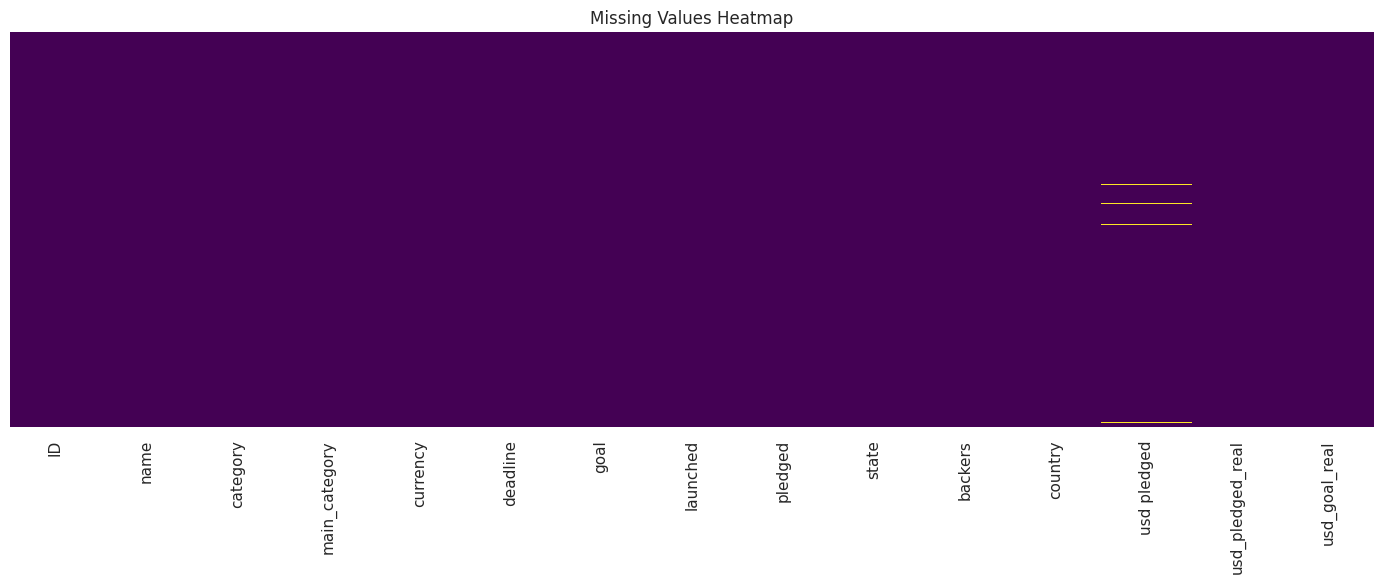

In [15]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("reports/figures/missing_values_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

missing_summary.to_csv("reports/missing_values_summary.csv", index=True)


### Duplicates

In [16]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("DUPLICATE ROW ANALYSIS")
print(f"Duplicate Rows       : {duplicate_count:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.4f}%")
print(f"Duplicate IDs        : {df['ID'].duplicated().sum()}")

DUPLICATE ROW ANALYSIS
Duplicate Rows       : 0
Duplicate Percentage : 0.0000%
Duplicate IDs        : 0


### Data types

In [17]:
dtype_summary = pd.DataFrame({
    "Storage Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})
dtype_summary


,Storage Type,Missing Values,Unique Values
ID,int64,0,378661
name,object,4,375722
category,object,0,159
main_category,object,0,15
currency,object,0,14
deadline,object,0,3164
goal,float64,0,8353
launched,object,0,347035
pledged,float64,0,62130
state,object,0,6


In [18]:
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features ({len(numerical_columns)}):   {numerical_columns}")
print(f"Categorical Features ({len(categorical_columns)}): {categorical_columns}")

Numerical Features (7):   ['ID', 'goal', 'pledged', 'backers', 'usd pledged', 'usd_pledged_real', 'usd_goal_real']
Categorical Features (8): ['name', 'category', 'main_category', 'currency', 'deadline', 'launched', 'state', 'country']


### Numerical & categorical summaries

In [19]:
numerical_summary = df.describe().T
numerical_summary["skewness"] = df.skew(numeric_only=True)
numerical_summary["kurtosis"] = df.kurtosis(numeric_only=True)
numerical_summary = numerical_summary.round(3)
numerical_summary

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ID,378661.0,1.074731e+09,6.190862e+08,5971.00,5.382635e+08,1.075276e+09,1.610149e+09,2.147476e+09,-0.003,-1.198
goal,378661.0,4.908079e+04,1.183391e+06,0.01,2.000000e+03,5.200000e+03,1.600000e+04,1.000000e+08,70.799,5574.952
pledged,378661.0,9.682979e+03,9.563601e+04,0.00,3.000000e+01,6.200000e+02,4.076000e+03,2.033899e+07,75.152,10010.262
backers,378661.0,1.056170e+02,9.071850e+02,0.00,2.000000e+00,1.200000e+01,5.600000e+01,2.193820e+05,86.763,13954.938
usd pledged,374864.0,7.036729e+03,7.863974e+04,0.00,1.698000e+01,3.947200e+02,3.034090e+03,2.033899e+07,105.900,18960.922
usd_pledged_real,378661.0,9.058924e+03,9.097334e+04,0.00,3.100000e+01,6.243300e+02,4.050000e+03,2.033899e+07,82.188,11796.482
usd_goal_real,378661.0,4.545440e+04,1.152950e+06,0.01,2.000000e+03,5.500000e+03,1.550000e+04,1.663614e+08,78.221,7082.887


In [20]:
categorical_summary = df.describe(include=["object"]).T
categorical_summary


,count,unique,top,freq
name,378657,375722,#NAME?,43
category,378661,159,Product Design,22314
main_category,378661,15,Film & Video,63585
currency,378661,14,USD,295365
deadline,378661,3164,2014-08-08,705
launched,378661,347035,2017-06-20 16:00,15
state,378661,6,failed,197719
country,378661,23,US,292627


### Target variable: `state`

In [21]:
TARGET = "state"

target_counts = df[TARGET].value_counts(dropna=False)
target_percentage = df[TARGET].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({"Count": target_counts, "Percentage": target_percentage})
target_summary


,Count,Percentage
state,,
failed,197719,52.22
successful,133956,35.38
canceled,38779,10.24
undefined,3562,0.94
live,2799,0.74
suspended,1846,0.49


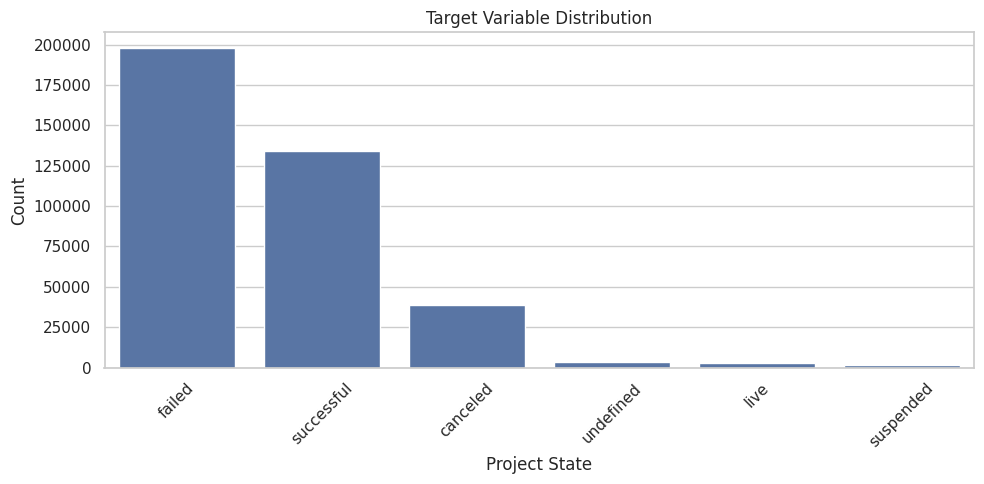

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x=TARGET, order=df[TARGET].value_counts().index)
plt.title("Target Variable Distribution")
plt.xlabel("Project State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/figures/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

target_summary.to_csv("reports/target_summary.csv")

In [23]:
binary_df = df[df[TARGET].isin(["successful", "failed"])].copy()
binary_df["target"] = (binary_df[TARGET] == "successful").astype(int)

print(f"Rows kept for modeling: {len(binary_df):,} ({len(binary_df)/len(df)*100:.1f}% of original)")
binary_df["target"].value_counts(normalize=True).round(3)


Rows kept for modeling: 331,675 (87.6% of original)


,proportion
target,
0,0.596
1,0.404


### Data quality red flags

In [24]:
print("Placeholder 'N,0' country rows:", (df["country"] == "N,0\'").sum() + (df["country"] == "N,0").sum())
print("Rows with goal <= 0:", (df["goal"] <= 0).sum())
print("Rows with usd_goal_real <= 0:", (df["usd_goal_real"] <= 0).sum())

launched_dt = pd.to_datetime(df["launched"], errors="coerce")
deadline_dt = pd.to_datetime(df["deadline"], errors="coerce")

print("Rows where deadline < launched:", (deadline_dt < launched_dt).sum())
print("Rows with 'launched' year <= 1971 (epoch bug):", (launched_dt.dt.year <= 1971).sum())

Placeholder 'N,0' country rows: 0
Rows with goal <= 0: 0
Rows with usd_goal_real <= 0: 0
Rows where deadline < launched: 0
Rows with 'launched' year <= 1971 (epoch bug): 7


### Day 1 summary

In [25]:
memory_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

eda_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Memory Usage (MB)", "Duplicate Rows",
               "Target Variable", "Target Classes", "Numerical Features",
               "Categorical Features"],
    "Value": [rows, columns, round(memory_usage_mb, 2), duplicate_count,
              TARGET, df[TARGET].nunique(), len(numerical_columns), len(categorical_columns)]
})

eda_summary.to_csv("reports/eda_summary.csv", index=False)
eda_summary


,Metric,Value
0,Rows,378661
1,Columns,15
2,Memory Usage (MB),194.51
3,Duplicate Rows,0
4,Target Variable,state
5,Target Classes,6
6,Numerical Features,7
7,Categorical Features,8


---
# Day 2 — Visual EDA


### Country distribution


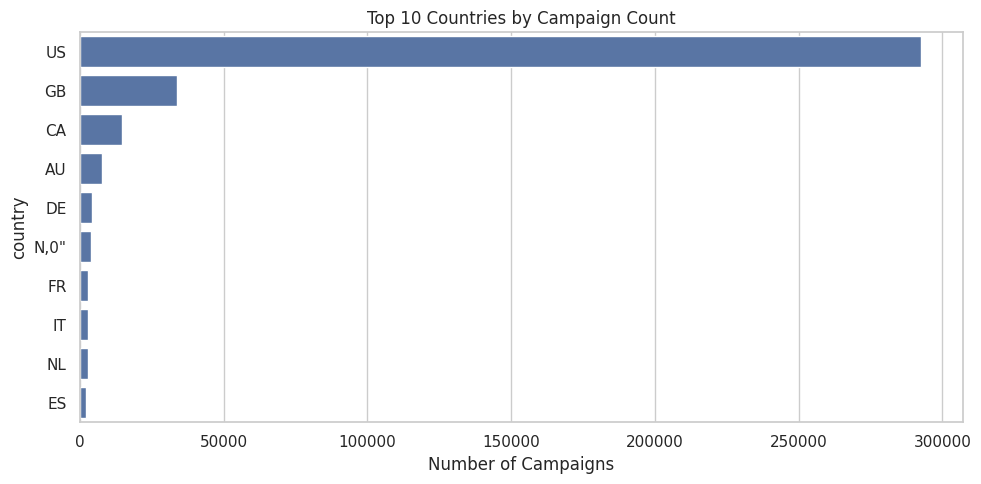

In [26]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Campaign Count")
plt.xlabel("Number of Campaigns")
plt.tight_layout()
plt.savefig("reports/figures/country_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Category distribution

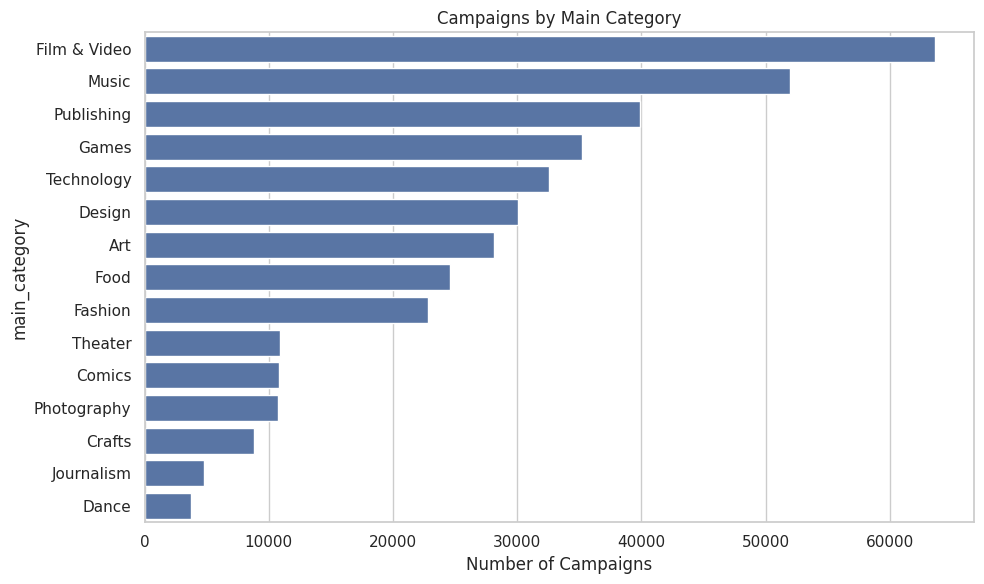

In [27]:
top_cat = df["main_category"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Campaigns by Main Category")
plt.xlabel("Number of Campaigns")
plt.tight_layout()
plt.savefig("reports/figures/category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Funding distribution (usd_pledged_real, log scale)

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["usd_pledged_real"]), bins=50)
plt.title("Distribution of log(1 + USD Pledged)")
plt.xlabel("log(1 + usd_pledged_real)")
plt.tight_layout()
plt.savefig("reports/figures/funding_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


count    331675.000000
mean         32.956433
std          12.713349
min           0.000000
25%          29.000000
50%          29.000000
75%          35.000000
max          91.000000
Name: duration_days, dtype: float64


### Goal distribution (usd_goal_real, log scale)

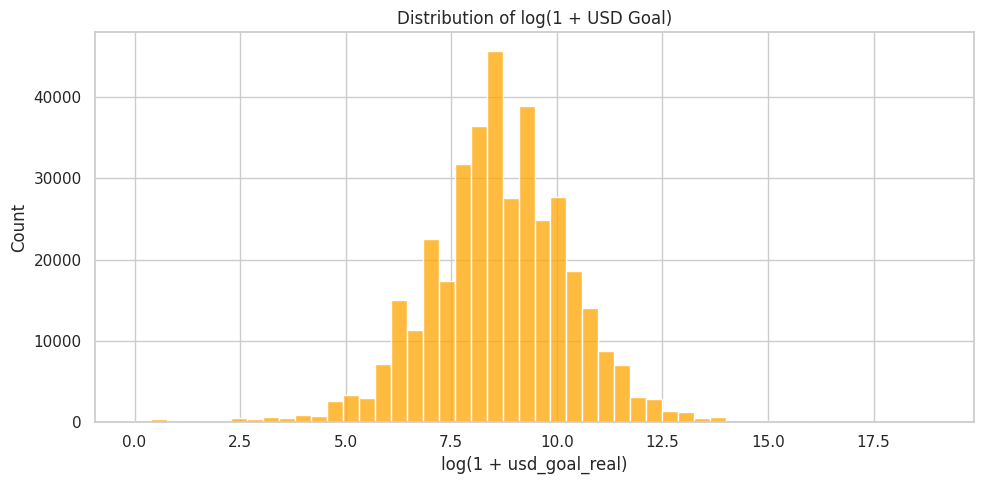

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["usd_goal_real"]), bins=50, color="orange")
plt.title("Distribution of log(1 + USD Goal)")
plt.xlabel("log(1 + usd_goal_real)")
plt.tight_layout()
plt.savefig("reports/figures/goal_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Campaign duration

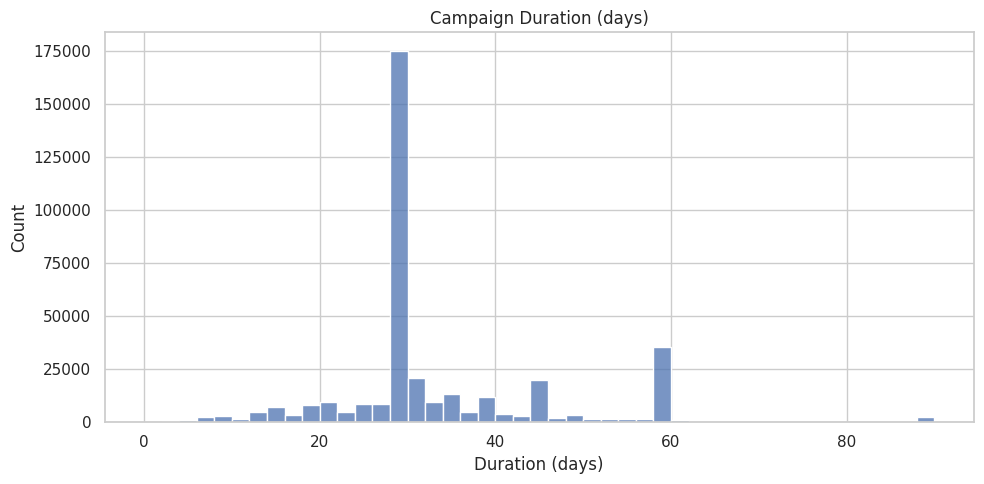

,0
count,378661.000000
mean,33.482608
std,65.909166
min,0.000000
25%,29.000000
50%,29.000000
75%,36.000000
max,16738.000000


In [29]:
campaign_duration = (deadline_dt - launched_dt).dt.days

plt.figure(figsize=(10, 5))
sns.histplot(campaign_duration[campaign_duration.between(0, 90)], bins=45)
plt.title("Campaign Duration (days)")
plt.xlabel("Duration (days)")
plt.tight_layout()
plt.savefig("reports/figures/campaign_duration.png", dpi=300, bbox_inches="tight")
plt.show()

campaign_duration.describe()


### Correlation matrix (numeric columns)

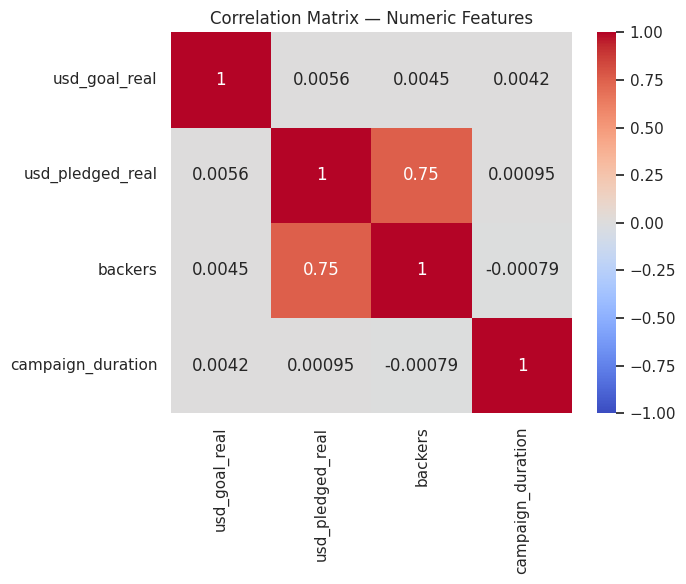

In [30]:
corr_cols = ["usd_goal_real", "usd_pledged_real", "backers"]
corr_df = df[corr_cols].copy()
corr_df["campaign_duration"] = campaign_duration
corr = corr_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("reports/figures/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
